# Hypothesis testing  example 


In [4]:
import os


In [39]:
data_path = "Experimentation/data/ab-testing-dataset"
print(os.listdir(data_path))

['test_group.csv', 'control_group.csv']


In [40]:
import pandas as pd

data_path = "Experimentation/data/ab-testing-dataset"

control_df = pd.read_csv(os.path.join(data_path, "control_group.csv"), sep=";")
test_df = pd.read_csv(os.path.join(data_path, "test_group.csv"), sep=";")

print("Control:", control_df.shape)
print("Test:", test_df.shape)
control_df.head()

Control: (30, 10)
Test: (30, 10)


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
from IPython.display import display, HTML

display(HTML("<h4>Control Group</h4>"))
display(control_df.head())
display(HTML("<h4>Test Group</h4>"))
display(test_df.head())

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Test Campaign,1.08.2019,3008,39550,35820,3038,1946,1069,894,255
1,Test Campaign,2.08.2019,2542,100719,91236,4657,2359,1548,879,677
2,Test Campaign,3.08.2019,2365,70263,45198,7885,2572,2367,1268,578
3,Test Campaign,4.08.2019,2710,78451,25937,4216,2216,1437,566,340
4,Test Campaign,5.08.2019,2297,114295,95138,5863,2106,858,956,768


In [42]:
def add_metrics(df):
    df = df.copy()
    df["CTR"]                = df["# of Website Clicks"] / df["# of Impressions"]
    df["Conversion Rate"]    = df["# of Purchase"] / df["# of Website Clicks"]
    df["Cost per Click"]     = df["Spend [USD]"] / df["# of Website Clicks"]
    df["Cost per Purchase"]  = df["Spend [USD]"] / df["# of Purchase"]
    df["Add-to-Cart Rate"]   = df["# of Add to Cart"] / df["# of View Content"]
    return df

control_df = add_metrics(control_df)
test_df    = add_metrics(test_df)
# Rename columns using a dictionary
test_df.rename(columns={'Spend [USD]': 'Spend', '# of Impressions': 'Impressions', '# of Website Clicks': 'Website Clicks', '# of Searches': 'Searches', '# of View Content': 'View Content', '# of Add to Cart': 'Add to Cart', '# of Purchase': 'Purchases' }, inplace=True)
control_df.rename(columns={'Spend [USD]': 'Spend', '# of Impressions': 'Impressions', '# of Website Clicks': 'Website Clicks', '# of Searches': 'Searches', '# of View Content': 'View Content', '# of Add to Cart': 'Add to Cart', '# of Purchase': 'Purchases' }, inplace=True)

metric_cols = ["Date", "CTR", "Conversion Rate", "Cost per Click", "Cost per Purchase", "Add-to-Cart Rate"]

from IPython.display import display, HTML
display(HTML("<h4>Control Group — Metrics</h4>"))
display(control_df[metric_cols].head(10))
display(HTML("<h4>Test Group — Metrics</h4>"))
display(test_df[metric_cols].head(10))

,Date,CTR,Conversion Rate,Cost per Click,Cost per Purchase,Add-to-Cart Rate
0,1.08.2019,0.084835,0.088084,0.324971,3.689320,0.842520
1,2.08.2019,0.067003,0.063009,0.216646,3.438356,0.662140
2,3.08.2019,0.049411,0.057160,0.360018,6.298387,0.732085
3,4.08.2019,0.042057,0.110930,0.632953,5.705882,1.204684
4,5.08.2019,NaN,NaN,NaN,NaN,NaN
5,6.08.2019,0.036928,0.189672,0.765392,4.035340,0.627702
6,7.08.2019,0.018575,0.189015,0.963636,5.098196,1.054250
7,8.08.2019,0.079834,0.063636,0.261708,4.112554,0.338674
8,9.08.2019,0.051083,0.080833,0.453856,5.614770,0.296007
9,10.08.2019,0.019358,0.322354,0.943786,2.927793,0.821069


,Date,CTR,Conversion Rate,Cost per Click,Cost per Purchase,Add-to-Cart Rate
0,1.08.2019,0.076814,0.083937,0.990125,11.796078,0.836296
1,2.08.2019,0.046238,0.145373,0.545845,3.754801,0.567829
2,3.08.2019,0.112221,0.073304,0.299937,4.091696,0.535699
3,4.08.2019,0.053741,0.080645,0.642789,7.970588,0.393876
4,5.08.2019,0.051297,0.130991,0.391779,2.990885,1.114219
5,6.08.2019,0.175429,0.065171,0.328259,5.036885,0.821994
6,7.08.2019,0.078187,0.210851,0.672353,3.188764,0.596242
7,8.08.2019,0.213371,0.059994,0.405902,6.765661,0.565178
8,9.08.2019,0.181473,0.102313,0.321104,3.138462,0.434625
9,10.08.2019,0.085478,0.033846,0.343385,10.145455,0.235033


In [43]:
# metrics to compare :
# Conversion Rate (Purchases / Website Clicks) -> Higher is better.
# Cost per Click (Spend / Website Clicks) -> Lower is better.
# Cost per Purchase (Spend / Purchases) -> Lower is better.
# Click-through Rate (Website Clicks / Impressions) -> Higher is better.


In [44]:
control_df.head(1)


,Campaign Name,Date,Spend,Impressions,Reach,Website Clicks,Searches,View Content,Add to Cart,Purchases,CTR,Conversion Rate,Cost per Click,Cost per Purchase,Add-to-Cart Rate
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,0.084835,0.088084,0.324971,3.68932,0.84252


In [45]:
test_df.head(1)

,Campaign Name,Date,Spend,Impressions,Reach,Website Clicks,Searches,View Content,Add to Cart,Purchases,CTR,Conversion Rate,Cost per Click,Cost per Purchase,Add-to-Cart Rate
0,Test Campaign,1.08.2019,3008,39550,35820,3038,1946,1069,894,255,0.076814,0.083937,0.990125,11.796078,0.836296


In [46]:
control_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Campaign Name,30,1,Control Campaign,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,30,30,1.08.2019,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Spend,30.0,NaN,NaN,NaN,2288.433333,367.334451,1757.0,1945.5,2299.5,2532.0,3083.0
Impressions,29.0,NaN,NaN,NaN,109559.758621,21688.922908,71274.0,92029.0,113430.0,121332.0,145248.0
Reach,29.0,NaN,NaN,NaN,88844.931034,21832.349595,42859.0,74192.0,91579.0,102479.0,127852.0
Website Clicks,29.0,NaN,NaN,NaN,5320.793103,1757.369003,2277.0,4085.0,5224.0,6628.0,8137.0
Searches,29.0,NaN,NaN,NaN,2221.310345,866.089368,1001.0,1615.0,2390.0,2711.0,4891.0
View Content,29.0,NaN,NaN,NaN,1943.793103,777.545469,848.0,1249.0,1984.0,2421.0,4219.0
Add to Cart,29.0,NaN,NaN,NaN,1300.0,407.457973,442.0,930.0,1339.0,1641.0,1913.0
Purchases,29.0,NaN,NaN,NaN,522.793103,185.028642,222.0,372.0,501.0,670.0,800.0


In [52]:
control_df[control_df["Impressions"].isnull() == False].head(1)

,Campaign Name,Date,Spend,Impressions,Reach,Website Clicks,Searches,View Content,Add to Cart,Purchases,CTR,Conversion Rate,Cost per Click,Cost per Purchase,Add-to-Cart Rate
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,0.084835,0.088084,0.324971,3.68932,0.84252


In [48]:
control_df["Date"] = pd.to_datetime(control_df["Date"], format="%d.%m.%Y")
test_df["Date"]    = pd.to_datetime(test_df["Date"], format="%d.%m.%Y")

print("Control — Date range:", control_df["Date"].min(), "to", control_df["Date"].max())
print("Test    — Date range:", test_df["Date"].min(), "to", test_df["Date"].max())

Control — Date range: 2019-08-01 00:00:00 to 2019-08-30 00:00:00
Test    — Date range: 2019-08-01 00:00:00 to 2019-08-30 00:00:00


## A/B testing :  CTR  

In [62]:
control_impressions = control_df["Impressions"].sum()
control_clicks      = control_df["Website Clicks"].sum()
control_ctr         = control_clicks / control_impressions

test_impressions    = test_df["Impressions"].sum()
test_clicks         = test_df["Website Clicks"].sum()
test_ctr            = test_clicks / test_impressions

print(f"Control — Impressions: {control_impressions:,.0f} | Clicks: {control_clicks:,.0f} | CTR: {control_ctr:.4f}")
print(f"Test    — Impressions: {test_impressions:,.0f} | Clicks: {test_clicks:,.0f} | CTR: {test_ctr:.4f}")

Control — Impressions: 3,177,233 | Clicks: 154,303 | CTR: 0.0486
Test    — Impressions: 2,237,544 | Clicks: 180,970 | CTR: 0.0809


### Hypothesis

- **H₀**: CTR_test is same as the CTR_control — the website change had no effect on CTR
- **H₁**: CTR_test > CTR_control — the website change improved CTR

**Test type**: One-tailed (right-sided)  
**Significance level**: α = 0.10 (90% confidence)

### Step 1 — Sample Size Check

Before running any proportion test, we need to confirm the sample size is large enough for the normal approximation to be valid.

For a proportion test, **n** is not the number of days — it's the total number of trials (impressions), since each impression is one opportunity for a click to happen.

**Rule of thumb**: n ≥ 30 per group.

In [63]:
n_control = control_df["Impressions"].sum()
n_test    = test_df["Impressions"].sum()

print(f"Control impressions (n): {n_control:,.0f}")
print(f"Test impressions (n):    {n_test:,.0f}")
print()
print(f"Control n ≥ 30: {n_control >= 30}")
print(f"Test n ≥ 30:    {n_test >= 30}")

Control impressions (n): 3,177,233
Test impressions (n):    2,237,544

Control n ≥ 30: True
Test n ≥ 30:    True


### Step 2 — Success-Failure Condition (Normality Check)

The z-test requires the sampling distribution of p̂ (CTR) to be approximately normal. But CTR is a proportion bounded between 0 and 1 — it only becomes approximately normal when the sample is large enough. This is guaranteed by the **Central Limit Theorem**.

> **Central Limit Theorem (CLT)**: If you take a large enough random sample, the distribution of the sample mean (or proportion) will be approximately normal — regardless of the shape of the underlying population. The larger the sample, the closer it gets to a perfect bell curve.

**How we check it — the success-failure condition:**

```
n × p̂ > 10        → enough clicks (successes)
n × (1 - p̂) > 10  → enough non-clicks (failures)
```

Where:
- **n** = total impressions (number of trials)
- **p̂** = observed CTR (proportion of successes)

If both pass, the CLT has kicked in and the sampling distribution of p̂ is approximately normal → z-test is valid.

**Why not just plot CTR and check visually?**

We only have 29 daily CTR values — too few to judge normality from a histogram. The success-failure condition is the correct check because what needs to be normal is the *sampling distribution of p̂* (what you'd get if you repeated the experiment many times), not the 29 daily values themselves. With n = millions of impressions, the CLT applies strongly.

In [64]:
p_control = control_ctr
p_test    = test_ctr

print("Control:")
print(f"  n × p̂       = {n_control * p_control:,.1f}  → {'✓' if n_control * p_control > 10 else '✗'}")
print(f"  n × (1-p̂)   = {n_control * (1 - p_control):,.1f}  → {'✓' if n_control * (1 - p_control) > 10 else '✗'}")

print("\nTest:")
print(f"  n × p̂       = {n_test * p_test:,.1f}  → {'✓' if n_test * p_test > 10 else '✗'}")
print(f"  n × (1-p̂)   = {n_test * (1 - p_test):,.1f}  → {'✓' if n_test * (1 - p_test) > 10 else '✗'}")

Control:
  n × p̂       = 154,303.0  → ✓
  n × (1-p̂)   = 3,022,930.0  → ✓

Test:
  n × p̂       = 180,970.0  → ✓
  n × (1-p̂)   = 2,056,574.0  → ✓


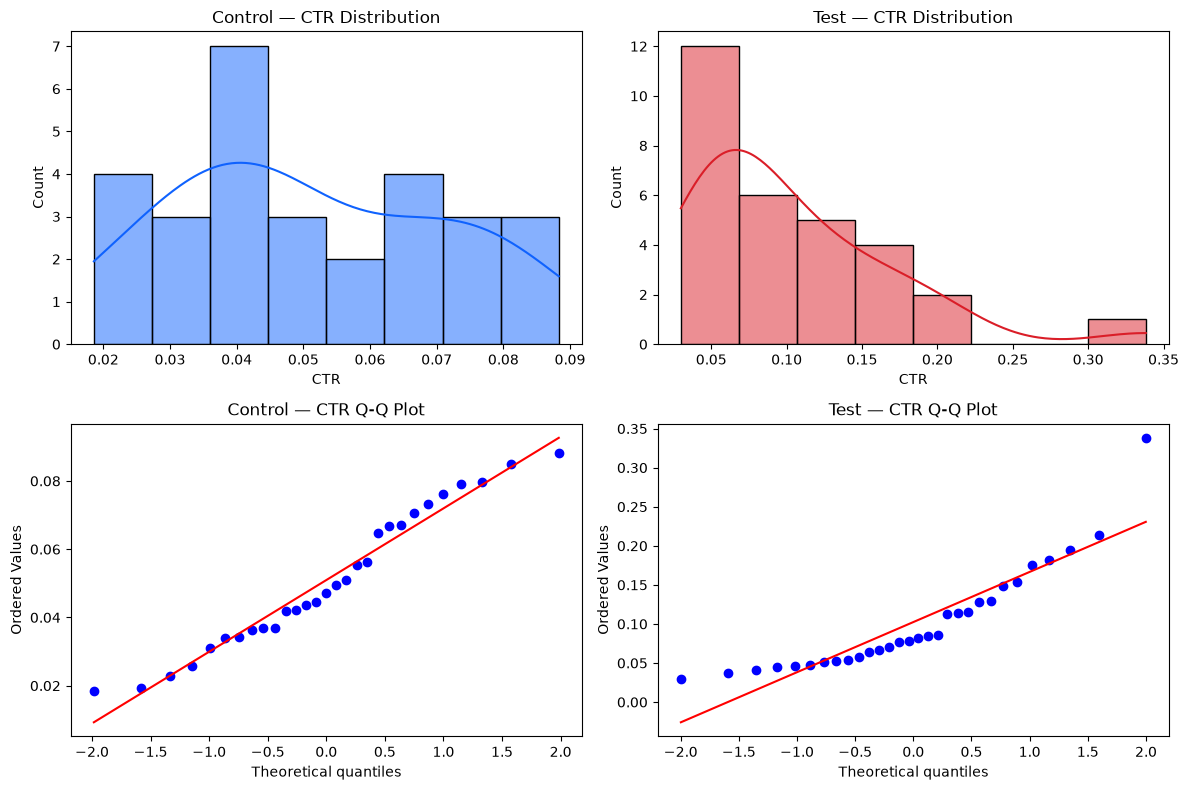

In [65]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Histograms with KDE
sns.histplot(control_df["CTR"].dropna(), kde=True, bins=8, ax=axes[0, 0], color="#0f62fe")
axes[0, 0].set_title("Control — CTR Distribution")
axes[0, 0].set_xlabel("CTR")

sns.histplot(test_df["CTR"].dropna(), kde=True, bins=8, ax=axes[0, 1], color="#da1e28")
axes[0, 1].set_title("Test — CTR Distribution")
axes[0, 1].set_xlabel("CTR")

# Q-Q plots
stats.probplot(control_df["CTR"].dropna(), plot=axes[1, 0])
axes[1, 0].set_title("Control — CTR Q-Q Plot")

stats.probplot(test_df["CTR"].dropna(), plot=axes[1, 1])
axes[1, 1].set_title("Test — CTR Q-Q Plot")

plt.tight_layout()
plt.show()

#### Reading the plots above

**Histogram + KDE** shows the shape of the daily CTR values. A bell-shaped curve suggests normality, but with only 29 points it will look noisy — don't over-interpret it.

**Q-Q Plot (Quantile-Quantile)**

A Q-Q plot compares your data's quantiles against what they *would be* if the data were perfectly normal:
- The **red diagonal line** represents perfect normality
- **Points hugging the line** → data is approximately normal
- **Points curving away at the ends (tails)** → skewed distribution, deviates from normal

Why do we need one? The histogram can be misleading with small samples — the Q-Q plot gives a more precise read on whether the tails deviate from normality, which matters most for statistical tests.

> **Note**: These plots are exploratory — they show the 29 daily CTR values. The formal normality guarantee for the z-test comes from the success-failure condition above, not from these charts.

### Step 3 — Two-Proportion Z-Test

Both groups passed the success-failure condition, so we can proceed with the **two-proportion z-test**.

Under H₀ we assume both groups share the same true proportion, so we estimate a **pooled proportion** by combining both groups:

```
p̂_pooled = (clicks_control + clicks_test) / (n_control + n_test)

SE = √[ p̂_pooled × (1 - p̂_pooled) × (1/n_control + 1/n_test) ]

z = (p̂_test - p̂_control) / SE
```

Since this is a **one-tailed test** (H₁: CTR_test > CTR_control), we look at the right tail only:
- p-value = P(Z > z)
- Reject H₀ if p-value < α = 0.10

In [69]:
import numpy as np
from scipy import stats

# Pooled proportion under H₀
p_pooled = (control_clicks + test_clicks) / (n_control + n_test)

# Standard error
se = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_control + 1/n_test))

# Z-statistic
z = (test_ctr - control_ctr) / se

# One-tailed p-value (right tail)
p_value = 1 - stats.norm.cdf(z)

print(f"Pooled CTR:  {p_pooled:.4f}")
print(f"Z-statistic: {z:.4f}")
print(f"P-value:     {p_value:.6f}")
print()
if p_value < 0.10:
    print("✓ Reject H₀ — Test CTR is significantly higher than Control CTR at 90% confidence")
else:
    print("✗ Fail to reject H₀ — Not enough evidence that Test CTR is higher")

Pooled CTR:  0.0619
Z-statistic: 153.6302
P-value:     0.000000

✓ Reject H₀ — Test CTR is significantly higher than Control CTR at 90% confidence


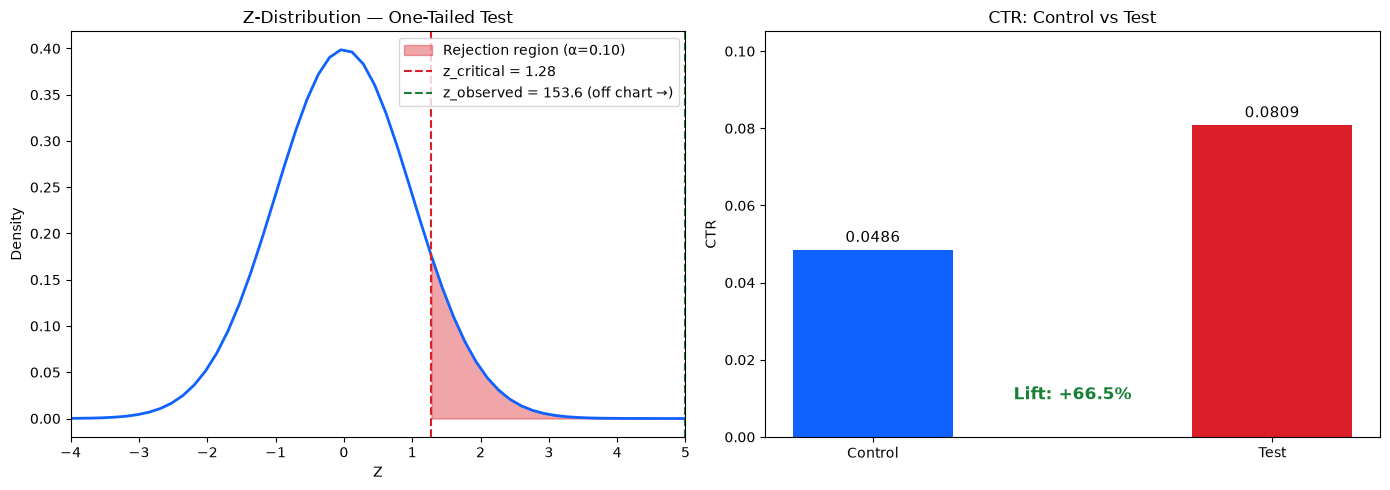

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Normal distribution curve
x = np.linspace(-5, 160, 1000)
y = stats.norm.pdf(x, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Z distribution with rejection region ---
ax = axes[0]
ax.plot(x, y, color="#0f62fe", linewidth=2)

# Rejection region (right tail, one-tailed α=0.10 → z_critical=1.28)
z_crit = stats.norm.ppf(0.90)
x_fill = np.linspace(z_crit, 5, 300)
ax.fill_between(x_fill, stats.norm.pdf(x_fill, 0, 1), color="#da1e28", alpha=0.4, label=f"Rejection region (α=0.10)")
ax.axvline(z_crit, color="#da1e28", linestyle="--", label=f"z_critical = {z_crit:.2f}")
ax.axvline(min(z, 5), color="#198038", linestyle="--", label=f"z_observed = {z:.1f} (off chart →)")
ax.set_xlim(-4, 5)
ax.set_title("Z-Distribution — One-Tailed Test")
ax.set_xlabel("Z")
ax.set_ylabel("Density")
ax.legend()

# --- Plot 2: CTR comparison bar chart ---
ax2 = axes[1]
groups = ["Control", "Test"]
ctrs   = [control_ctr, test_ctr]
colors = ["#0f62fe", "#da1e28"]

bars = ax2.bar(groups, ctrs, color=colors, width=0.4)
ax2.set_title("CTR: Control vs Test")
ax2.set_ylabel("CTR")
ax2.set_ylim(0, max(ctrs) * 1.3)

for bar, val in zip(bars, ctrs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{val:.4f}", ha="center", fontsize=11)

ax2.text(0.5, max(ctrs) * 1.15, f"Lift: +{((test_ctr - control_ctr)/control_ctr)*100:.1f}%",
         ha="center", transform=ax2.get_xaxis_transform(), fontsize=12, color="#198038", fontweight="bold")

plt.tight_layout()
plt.show()

### Alternative — T-Test on Daily CTR (Continuous Metric Framing)

Instead of treating CTR as a proportion across millions of impressions, we can treat each day's CTR as one observation and compare the 29 daily values between groups using a **two-sample t-test**.

This framing asks: *"Is the average daily CTR of the test group significantly higher than control?"*

**When this makes sense**: when you only have aggregated daily data (not user-level), and you want to account for day-to-day variability in CTR.

**Assumptions**:
- Daily CTR values are approximately normally distributed ← checked via Q-Q plots above
- The two groups are independent

**Test**: One-tailed (H₁: mean CTR_test > mean CTR_control), α = 0.10

In [71]:
from scipy import stats

control_daily_ctr = control_df["CTR"].dropna()
test_daily_ctr    = test_df["CTR"].dropna()

# Welch's t-test (does not assume equal variance)
t_stat, p_two_tailed = stats.ttest_ind(test_daily_ctr, control_daily_ctr, equal_var=False)

# One-tailed p-value (right tail)
p_value_t = p_two_tailed / 2 if t_stat > 0 else 1 - p_two_tailed / 2

print(f"Control mean daily CTR: {control_daily_ctr.mean():.4f}")
print(f"Test mean daily CTR:    {test_daily_ctr.mean():.4f}")
print(f"T-statistic:            {t_stat:.4f}")
print(f"P-value (one-tailed):   {p_value_t:.6f}")
print()
if p_value_t < 0.10:
    print("✓ Reject H₀ — Test CTR is significantly higher than Control CTR at 90% confidence")
else:
    print("✗ Fail to reject H₀ — Not enough evidence that Test CTR is higher")

Control mean daily CTR: 0.0510
Test mean daily CTR:    0.1024
T-statistic:            3.9786
P-value (one-tailed):   0.000169

✓ Reject H₀ — Test CTR is significantly higher than Control CTR at 90% confidence
